# Short Answer Grading  Automatic Scoring with NLP

**Dataset:** ASAG2024

## Evaluation Metrics

Four metrics are reported for every method:
- **Pearson r** : linear correlation between predicted and human scores (higher is better)
- **MAE** : mean absolute error on continuous scores (lower is better)
- **QWK** : quadratic weighted kappa on 3-class binned scores: Low (0–0.33), Medium (0.33–0.66), High (0.66–1.0). Penalises large disagreements more than small ones (higher is better, 1.0 = perfect)

- **RMSE**

## Step 1  Install & Import Libraries

In [1]:
!pip install -q datasets sentence-transformers scikit-learn huggingface_hub

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    cohen_kappa_score, confusion_matrix, classification_report
)
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries loaded. Using device: {DEVICE}')

Libraries loaded. Using device: cpu


### Metric Helper Functions

We define all three evaluation metrics once and reuse them throughout.

**Binning rule for QWK:** continuous score → 3 integer classes
- 0 = Low (0.00 – 0.33)
- 1 = Medium (0.33 – 0.66)
- 2 = High (0.66 – 1.00)

In [3]:
def bin_scores(scores, n_classes=5):
    scores = np.asarray(scores)
    bins = np.zeros(len(scores), dtype=int)
    thresholds = [0.2, 0.4, 0.6, 0.8]   # 5 equal bins on [0,1]
    for i, t in enumerate(thresholds):
        bins[scores >= t] = i + 1
    return bins

def compute_metrics(y_true, y_pred, label=''):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    mae           = mean_absolute_error(y_true, y_pred)
    rmse          = np.sqrt(mean_squared_error(y_true, y_pred))
    qwk           = cohen_kappa_score(bin_scores(y_true), bin_scores(y_pred), weights='quadratic')
    print(f'=== {label} ===')
    print(f'  Pearson r : {pearson_r:.4f}')
    print(f'  MAE       : {mae:.4f}')
    print(f'  RMSE      : {rmse:.4f}')
    print(f'  QWK       : {qwk:.4f}\n')
    return {'Method': label, 'Pearson r': round(pearson_r,4),
            'MAE': round(mae,4), 'RMSE': round(rmse,4), 'QWK': round(qwk,4)}

## Step 2  Load & Inspect ASAG2024

ASAG2024 contains 45,193 student answers across 283 questions from 7 data sources (SciEntsBank, Beetle, Mohler, SAF, Stita, DigiKlausur), pre-split into train/validation/test.  
We load via parquet to bypass a known schema conflict bug in the `datasets` library for this dataset.

In [4]:
train_raw = pd.read_parquet('hf://datasets/Meyerger/ASAG2024/train.parquet')
test_raw  = pd.read_parquet('hf://datasets/Meyerger/ASAG2024/test.parquet')
val_raw = pd.read_parquet('hf://datasets/Meyerger/ASAG2024/validation.parquet')

print('Raw train shape:', train_raw.shape)
print('Raw test shape :', test_raw.shape)
print('Raw val shape:', val_raw.shape)
print('\nColumns:', train_raw.columns.tolist())
print('\nMissing values (train):')
print(train_raw.isnull().sum())
train_raw.head(3)

Raw train shape: (15190, 7)
Raw test shape : (1899, 7)
Raw val shape: (1899, 7)

Columns: ['question', 'provided_answer', 'reference_answer', 'grade', 'data_source', 'normalized_grade', 'weight']

Missing values (train):
question            914
provided_answer      37
reference_answer      0
grade                 0
data_source           0
normalized_grade      0
weight                0
dtype: int64


,question,provided_answer,reference_answer,grade,data_source,normalized_grade,weight
index,,,,,,,
4262,"Look at the 2 pictures of drops on a flat, wat...",The plain water looks like it does because pla...,Surface tension causes the plain water to look...,0.0,SciEntsBank,0.0,0.000092
22,What is the “Dynamic Host Configuration Protoc...,The Dynamic Host Configuration Protocol (DHCP)...,The Dynamic Host Configuration Protocol (DHCP)...,1.0,SAF,1.0,0.000080
2034,Why does the level of the water in the straw g...,Because the hotter it is the higher it goes up.,Water expands when water is heated.,0.0,SciEntsBank,0.0,0.000092


## Step 3 Exploratory Data Analysis

We examine the score distribution, sample breakdown per data source, answer lengths, and the 3-class bin distribution.
Understanding skew is important because it motivates our choice of Pearson r, MAE, and QWK over simple accuracy.

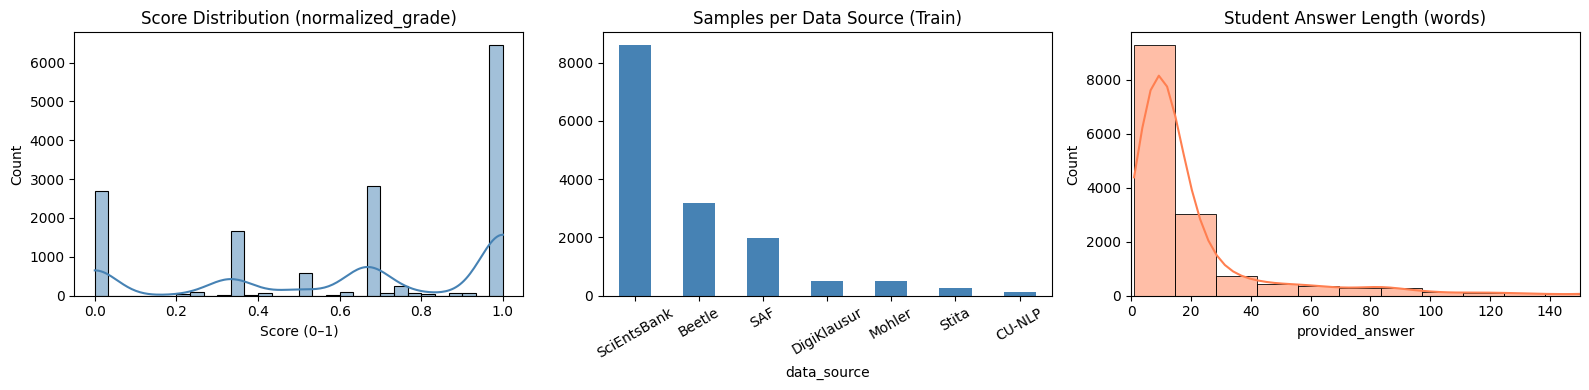

Score stats (train):
count    15190.0000
mean         0.6456
std          0.3766
min          0.0000
25%          0.3333
50%          0.6667
75%          1.0000
max          1.0000
Name: normalized_grade, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(train_raw['normalized_grade'].dropna(), bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Score Distribution (normalized_grade)')
axes[0].set_xlabel('Score (0–1)')

train_raw['data_source'].value_counts().plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Samples per Data Source (Train)')
axes[1].tick_params(axis='x', rotation=30)

lengths = train_raw['provided_answer'].dropna().str.split().str.len()
sns.histplot(lengths, bins=40, kde=True, color='coral', ax=axes[2])
axes[2].set_title('Student Answer Length (words)')
axes[2].set_xlim(0, 150)

plt.tight_layout()
plt.show()
print('Score stats (train):')
print(train_raw['normalized_grade'].describe().round(4))

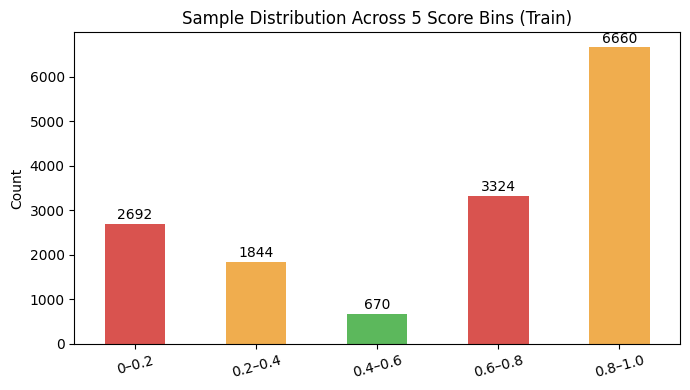

In [6]:
binned = bin_scores(train_raw['normalized_grade'].dropna().values)
bin_counts = pd.Series(binned).value_counts().sort_index()
bin_counts.index = ['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0']

fig, ax = plt.subplots(figsize=(7, 4))
bin_counts.plot(kind='bar', color=['#d9534f','#f0ad4e','#5cb85c'], ax=ax)
ax.set_title('Sample Distribution Across 5 Score Bins (Train)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height())}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Step 4  Data Cleaning


In [7]:
def clean_df(df):
    df = df.dropna(subset=['question','provided_answer','reference_answer','normalized_grade'])
    df = df.drop_duplicates(subset=['question','provided_answer','reference_answer','normalized_grade'])

    for col in ['provided_answer','reference_answer','question']:
        df[col] = df[col].apply(
            lambda x: re.sub(r'\s+', ' ', re.sub(r'<[^>]+>', ' ', str(x))).strip()
        )
    return df.rename(columns={
        'provided_answer' : 'student_answer',
        'reference_answer': 'instructor_answer',
        'normalized_grade': 'score'
    }).reset_index(drop=True)

train_df = clean_df(train_raw)
test_df  = clean_df(test_raw)
val_df = clean_df(val_raw)
print(f'Val  : {len(val_df)} rows  (removed {len(val_raw)-len(val_df)})')
print(f'Train: {len(train_df)} rows  (removed {len(train_raw)-len(train_df)})')
print(f'Test : {len(test_df)} rows  (removed {len(test_raw)-len(test_df)})')

Val  : 1759 rows  (removed 140)
Train: 13861 rows  (removed 1329)
Test : 1775 rows  (removed 124)


## Step 5  Text Preprocessing

We lowercase, remove punctuation, tokenize, remove stopwords, and lemmatize each answer.
This cleaned text is used for vocabulary-based features (common words, TF-IDF, BiLSTM).
Raw text is kept separately for SBERT, which has its own internal tokenizer.

In [8]:
for pkg in ['punkt','punkt_tab','stopwords','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    return ' '.join(
        lemmatizer.lemmatize(t)
        for t in word_tokenize(text)
        if t not in stop_words
    )

for df_ in [train_df,val_df ,test_df]:
    df_['clean_stu'] = df_['student_answer'].apply(preprocess)
    df_['clean_ref'] = df_['instructor_answer'].apply(preprocess)

print('Preprocessing done.')
print('Original :', train_df['student_answer'].iloc[0])
print('Cleaned  :', train_df['clean_stu'].iloc[0])

Preprocessing done.
Original : The plain water looks like it does because plain water is supposed to turn into a dome when it is on a flat surface.
Cleaned  : plain water look like plain water supposed turn dome flat surface


## Step 6  Feature 1: Common Word Count

The number of unique words shared between the cleaned student and reference answers  the lexical overlap baseline described in the project specification.
Normalised to [0,1] for consistent scale with the other features.

In [9]:
results_table = []

def common_word_count(s1, s2):
    return float(len(set(str(s1).split()) & set(str(s2).split())))

for df_ in [train_df, test_df]:
    df_['common_words'] = df_.apply(
        lambda r: common_word_count(r['clean_ref'], r['clean_stu']), axis=1
    )

max_cw = train_df['common_words'].max()
train_df['common_words_norm'] = train_df['common_words'] / max_cw
test_df['common_words_norm']  = test_df['common_words']  / max_cw

res = compute_metrics(test_df['score'], test_df['common_words_norm'], 'Common Word Count')
results_table.append(res)

=== Common Word Count ===
  Pearson r : 0.2891
  MAE       : 0.5783
  RMSE      : 0.6745
  QWK       : 0.0197



## Step 7  Feature 2: TF-IDF Cosine Similarity

TF-IDF weights each word by how distinctive it is across the corpus, downweighting common function words.
Cosine similarity between student and reference TF-IDF vectors gives a lexical similarity score in [0,1].
The vectorizer is fitted on training text only to prevent data leakage.

In [10]:
tfidf = TfidfVectorizer()
tfidf.fit(pd.concat([train_df['clean_ref'], train_df['clean_stu']]))

def compute_tfidf_sim(df_):
    ref_vecs = tfidf.transform(df_['clean_ref'])
    stu_vecs = tfidf.transform(df_['clean_stu'])
    return [cosine_similarity(ref_vecs[i], stu_vecs[i])[0][0] for i in range(len(df_))]

print('Computing TF-IDF similarities...')
train_df['tfidf_sim'] = compute_tfidf_sim(train_df)
test_df['tfidf_sim']  = compute_tfidf_sim(test_df)

res = compute_metrics(test_df['score'], test_df['tfidf_sim'], 'TF-IDF Cosine Similarity')
results_table.append(res)

Computing TF-IDF similarities...
=== TF-IDF Cosine Similarity ===
  Pearson r : 0.4020
  MAE       : 0.3962
  RMSE      : 0.4824
  QWK       : 0.2302



In [11]:
import torch.optim as optim

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# ── Encode train set ─────────────────────────────────────────────────
print('Encoding train set with SBERT...')
train_ref_emb = sbert_model.encode(
    train_df['instructor_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True
)
train_stu_emb = sbert_model.encode(
    train_df['student_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True
)

# ── Encode test set ──────────────────────────────────────────────────
print('Encoding test set with SBERT...')
test_ref_emb = sbert_model.encode(
    test_df['instructor_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True
)
test_stu_emb = sbert_model.encode(
    test_df['student_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True
)

# ── Compute cosine similarity scores ────────────────────────────────
print('Computing SBERT similarities...')
train_df['sbert_sim'] = torch.diagonal(util.cos_sim(train_ref_emb, train_stu_emb)).cpu().numpy()
test_df['sbert_sim']  = torch.diagonal(util.cos_sim(test_ref_emb,  test_stu_emb)).cpu().numpy()

res = compute_metrics(test_df['score'], test_df['sbert_sim'], 'SBERT Cosine Similarity')
results_table.append(res)

# ── Build pair embeddings ────────────────────────────────────────────
train_sbert_pairs = torch.cat([train_stu_emb, train_ref_emb], dim=1).cpu()
test_sbert_pairs  = torch.cat([test_stu_emb,  test_ref_emb],  dim=1).cpu()

print(f'Train SBERT pair matrix: {train_sbert_pairs.shape}')
print(f'Test  SBERT pair matrix: {test_sbert_pairs.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/217 [00:00<?, ?it/s]

Encoding test set with SBERT...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Computing SBERT similarities...
=== SBERT Cosine Similarity ===
  Pearson r : 0.4351
  MAE       : 0.2978
  RMSE      : 0.3577
  QWK       : 0.3729

Train SBERT pair matrix: torch.Size([13861, 768])
Test  SBERT pair matrix: torch.Size([1775, 768])


In [12]:
# ── MLP Head (only this trains — SBERT is frozen) ────────────────────
class SBERTGrader(nn.Module):
    def __init__(self, input_dim=768, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.head(x).squeeze(1)

# ── Dataset ──────────────────────────────────────────────────────────
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, scores):
        self.embeddings = embeddings.float()
        self.scores     = torch.tensor(scores, dtype=torch.float)
    def __len__(self): return len(self.scores)
    def __getitem__(self, i): return self.embeddings[i], self.scores[i]

sbert_loader = DataLoader(
    EmbeddingDataset(train_sbert_pairs, train_df['score'].values),
    batch_size=64, shuffle=True
)

# ── Training ─────────────────────────────────────────────────────────
sbert_grader = SBERTGrader().to(DEVICE)
sbert_opt    = Adam(sbert_grader.parameters(), lr=1e-3, weight_decay=1e-4)
sbert_crit   = nn.MSELoss()

#test_emb_t  = test_sbert_pairs.to(DEVICE)
#y_test      = test_df['score'].values
# AFTER
val_ref_emb = sbert_model.encode(val_df['instructor_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True)
val_stu_emb = sbert_model.encode(val_df['student_answer'].tolist(),
    convert_to_tensor=True, batch_size=64, show_progress_bar=True)
val_sbert_pairs = torch.cat([val_stu_emb, val_ref_emb], dim=1).cpu()

val_emb_t   = val_sbert_pairs.to(DEVICE)
test_emb_t  = test_sbert_pairs.to(DEVICE)
y_val       = val_df['score'].values
y_test      = test_df['score'].values

best_val_r  = -1.0
best_state  = None
patience    = 3
no_improve  = 0

print('Training SBERT grader (MLP head only)...')
for epoch in range(1, 16):
    sbert_grader.train()
    total_loss = 0.0
    for emb, scores in sbert_loader:
        emb, scores = emb.to(DEVICE), scores.to(DEVICE)
        sbert_opt.zero_grad()
        loss = sbert_crit(sbert_grader(emb), scores)
        loss.backward()
        sbert_opt.step()
        total_loss += loss.item() * emb.size(0)

    sbert_grader.eval()
    with torch.no_grad():
        #val_preds = sbert_grader(test_emb_t).cpu().numpy()
   # val_r, _ = pearsonr(val_preds, y_test)

        # AFTER
        val_preds = sbert_grader(val_emb_t).cpu().numpy()
    val_r, _ = pearsonr(val_preds, y_val)
    print(f'Epoch {epoch:2d}/15 — Loss: {total_loss/len(sbert_loader.dataset):.4f}  |  Val Pearson r: {val_r:.4f}')

    if val_r > best_val_r:
        best_val_r = val_r
        best_state = {k: v.clone() for k, v in sbert_grader.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break

sbert_grader.load_state_dict(best_state)
print(f'\nBest Val Pearson r: {best_val_r:.4f}')

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Training SBERT grader (MLP head only)...
Epoch  1/15 — Loss: 0.1229  |  Val Pearson r: 0.4856
Epoch  2/15 — Loss: 0.1043  |  Val Pearson r: 0.5432
Epoch  3/15 — Loss: 0.0940  |  Val Pearson r: 0.5592
Epoch  4/15 — Loss: 0.0871  |  Val Pearson r: 0.5941
Epoch  5/15 — Loss: 0.0808  |  Val Pearson r: 0.6014
Epoch  6/15 — Loss: 0.0754  |  Val Pearson r: 0.6177
Epoch  7/15 — Loss: 0.0712  |  Val Pearson r: 0.6361
Epoch  8/15 — Loss: 0.0672  |  Val Pearson r: 0.6597
Epoch  9/15 — Loss: 0.0637  |  Val Pearson r: 0.6615
Epoch 10/15 — Loss: 0.0611  |  Val Pearson r: 0.6738
Epoch 11/15 — Loss: 0.0590  |  Val Pearson r: 0.6623
Epoch 12/15 — Loss: 0.0567  |  Val Pearson r: 0.6763
Epoch 13/15 — Loss: 0.0547  |  Val Pearson r: 0.6684
Epoch 14/15 — Loss: 0.0527  |  Val Pearson r: 0.6850
Epoch 15/15 — Loss: 0.0502  |  Val Pearson r: 0.6864

Best Val Pearson r: 0.6864


In [13]:
sbert_grader.eval()
with torch.no_grad():
    train_emb_t = train_sbert_pairs.to(DEVICE)
    train_df['sbert_pred'] = sbert_grader(train_emb_t).cpu().numpy()
    test_df['sbert_pred']  = sbert_grader(test_emb_t).cpu().numpy()

train_r, _ = pearsonr(train_df['sbert_pred'], train_df['score'])
test_r,  _ = pearsonr(test_df['sbert_pred'],  test_df['score'])
print(f'SBERT Grader train Pearson r : {train_r:.4f}')
print(f'SBERT Grader test  Pearson r : {test_r:.4f}')
print(f'Train-test gap               : {train_r - test_r:.4f}')

res = compute_metrics(test_df['score'], test_df['sbert_pred'], 'SBERT Direct Predictor')
results_table.append(res)

SBERT Grader train Pearson r : 0.8574
SBERT Grader test  Pearson r : 0.6681
Train-test gap               : 0.1893
=== SBERT Direct Predictor ===
  Pearson r : 0.6681
  MAE       : 0.2101
  RMSE      : 0.2833
  QWK       : 0.6373



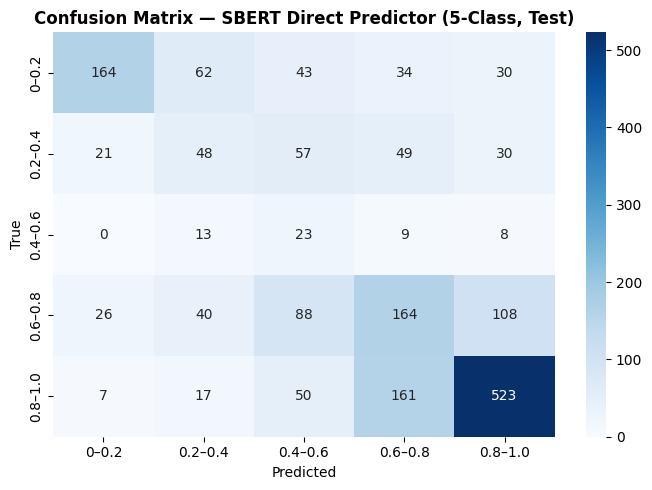

In [14]:
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(bin_scores(y_test), bin_scores(test_df['sbert_pred'].values), labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'],
            yticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix — SBERT Direct Predictor (5-Class, Test)', fontweight='bold')
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('True')
plt.tight_layout()
plt.show()

## Step 9  Feature 4: BiLSTM Direct Score Predictor (Deep Learning)

Unlike the previous similarity features, the BiLSTM is trained end-to-end to **predict the score directly**  not just measure similarity.

**Architecture:**
Both answers are encoded by a shared Bidirectional LSTM. The two vectors are concatenated and passed through an MLP head with sigmoid output → score in (0,1).

**Regularisation:** Dropout (p=0.4), weight decay (1e-4), early stopping on validation Pearson r.

In [15]:
# ── Vocabulary ───────────────────────────────────────────────────────
combined_text = " ".join(train_df['clean_stu']) + " " + " ".join(train_df['clean_ref'])
counts = Counter(combined_text.split())
vocab  = {word: idx+2 for idx,(word,_) in enumerate(counts.most_common(15000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
VOCAB_SIZE = len(vocab)
MAX_LEN    = 60

def encode_text(text):
    words   = str(text).split()
    encoded = [vocab.get(w,1) for w in words][:MAX_LEN]
    return encoded + [0]*(MAX_LEN-len(encoded))

train_stu_ids = [encode_text(t) for t in train_df['clean_stu']]
train_ref_ids = [encode_text(t) for t in train_df['clean_ref']]
test_stu_ids  = [encode_text(t) for t in test_df['clean_stu']]
test_ref_ids  = [encode_text(t) for t in test_df['clean_ref']]

class PairDataset(Dataset):
    def __init__(self, stu, ref, scores):
        self.stu    = torch.tensor(stu,    dtype=torch.long)
        self.ref    = torch.tensor(ref,    dtype=torch.long)
        self.scores = torch.tensor(scores, dtype=torch.float)
    def __len__(self): return len(self.scores)
    def __getitem__(self, i): return self.stu[i], self.ref[i], self.scores[i]

train_loader = DataLoader(
    PairDataset(train_stu_ids, train_ref_ids, train_df['score'].values),
    batch_size=64, shuffle=True
)

class BiLSTMGrader(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=128, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.emb_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(emb_dim, hid_dim, bidirectional=True,
                                  batch_first=True, dropout=dropout)
        self.out_drop  = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hid_dim*4, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def encode(self, x):
        emb = self.emb_drop(self.embedding(x))
        _, (h,_) = self.lstm(emb)
        return self.out_drop(torch.cat((h[-2],h[-1]), dim=1))
    def forward(self, stu, ref):
        return self.head(torch.cat([self.encode(stu), self.encode(ref)], dim=1)).squeeze(1)

lstm_model = BiLSTMGrader(VOCAB_SIZE).to(DEVICE)
optimizer  = Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion  = nn.MSELoss()

#val_stu_t = torch.tensor(test_stu_ids,  dtype=torch.long).to(DEVICE)
#val_ref_t = torch.tensor(test_ref_ids,  dtype=torch.long).to(DEVICE)
#y_test    = test_df['score'].values
# AFTER
val_stu_ids = [encode_text(t) for t in val_df['clean_stu']]
val_ref_ids = [encode_text(t) for t in val_df['clean_ref']]

val_stu_t  = torch.tensor(val_stu_ids, dtype=torch.long).to(DEVICE)
val_ref_t  = torch.tensor(val_ref_ids, dtype=torch.long).to(DEVICE)
test_stu_t = torch.tensor(test_stu_ids, dtype=torch.long).to(DEVICE)
test_ref_t = torch.tensor(test_ref_ids, dtype=torch.long).to(DEVICE)
y_val      = val_df['score'].values
y_test     = test_df['score'].values
best_val_r, best_state, patience, no_improve = -1.0, None, 3, 0

print('Training BiLSTM...')
for epoch in range(1, 16):
    lstm_model.train()
    total_loss = 0.0
    for stu, ref, scores in train_loader:
        stu, ref, scores = stu.to(DEVICE), ref.to(DEVICE), scores.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(lstm_model(stu, ref), scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * stu.size(0)
    lstm_model.eval()
    with torch.no_grad():
        #val_preds = lstm_model(val_stu_t, val_ref_t).cpu().numpy()
    #val_r, _ = pearsonr(val_preds, y_test)

        # AFTER
        val_preds = lstm_model(val_stu_t, val_ref_t).cpu().numpy()
    val_r, _ = pearsonr(val_preds, y_val)
    print(f'Epoch {epoch:2d}/15 — Loss: {total_loss/len(train_loader.dataset):.4f}  |  Val Pearson r: {val_r:.4f}')
    if val_r > best_val_r:
        best_val_r = val_r
        best_state = {k: v.clone() for k,v in lstm_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break

lstm_model.load_state_dict(best_state)
print(f'\nBest Val Pearson r: {best_val_r:.4f}')

Training BiLSTM...
Epoch  1/15 — Loss: 0.1321  |  Val Pearson r: 0.4595
Epoch  2/15 — Loss: 0.1150  |  Val Pearson r: 0.4979
Epoch  3/15 — Loss: 0.1094  |  Val Pearson r: 0.5039
Epoch  4/15 — Loss: 0.1057  |  Val Pearson r: 0.5202
Epoch  5/15 — Loss: 0.1039  |  Val Pearson r: 0.5300
Epoch  6/15 — Loss: 0.1019  |  Val Pearson r: 0.5455
Epoch  7/15 — Loss: 0.0987  |  Val Pearson r: 0.5569
Epoch  8/15 — Loss: 0.0967  |  Val Pearson r: 0.5684
Epoch  9/15 — Loss: 0.0936  |  Val Pearson r: 0.5799
Epoch 10/15 — Loss: 0.0909  |  Val Pearson r: 0.5991
Epoch 11/15 — Loss: 0.0887  |  Val Pearson r: 0.5926
Epoch 12/15 — Loss: 0.0859  |  Val Pearson r: 0.5918
Epoch 13/15 — Loss: 0.0826  |  Val Pearson r: 0.6055
Epoch 14/15 — Loss: 0.0801  |  Val Pearson r: 0.6006
Epoch 15/15 — Loss: 0.0777  |  Val Pearson r: 0.6114

Best Val Pearson r: 0.6114


In [16]:
print(len(test_df))
print(len(val_stu_ids))
print(len(val_ref_ids))

1775
1759
1759


In [17]:
lstm_model.eval()
with torch.no_grad():
    train_stu_t = torch.tensor(train_stu_ids, dtype=torch.long).to(DEVICE)
    train_ref_t = torch.tensor(train_ref_ids, dtype=torch.long).to(DEVICE)
    train_df['lstm_pred'] = lstm_model(train_stu_t, train_ref_t).cpu().numpy()
    #test_df['lstm_pred']  = lstm_model(val_stu_t,val_ref_t).cpu().numpy()
    test_df['lstm_pred'] = lstm_model(test_stu_t, test_ref_t).cpu().numpy()


train_r, _ = pearsonr(train_df['lstm_pred'], train_df['score'])
test_r,  _ = pearsonr(test_df['lstm_pred'],  test_df['score'])
print(f'BiLSTM train Pearson r : {train_r:.4f}')
print(f'BiLSTM test  Pearson r : {test_r:.4f}')
print(f'Train-test gap         : {train_r - test_r:.4f}')

res = compute_metrics(test_df['score'], test_df['lstm_pred'], 'BiLSTM Direct Predictor')
results_table.append(res)

BiLSTM train Pearson r : 0.7497
BiLSTM test  Pearson r : 0.5959
Train-test gap         : 0.1538
=== BiLSTM Direct Predictor ===
  Pearson r : 0.5959
  MAE       : 0.2356
  RMSE      : 0.3044
  QWK       : 0.5495



## Step 10  ML Regressors: SVR and Linear Regression

We combine all four features into a single matrix and train two regressors.
If SVR outperforms the best individual feature (BiLSTM), the features carry complementary information.

- **SVR (RBF kernel)**  captures non-linear relationships.
- **Linear Regression**  transparent baseline to check whether non-linearity actually helps.

In [18]:
FEATURES = ['common_words_norm', 'tfidf_sim', 'sbert_sim', 'lstm_pred']

X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values
y_train = train_df['score'].values

svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr.fit(X_train, y_train)
svr_preds = np.clip(svr.predict(X_test), 0, 1)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = np.clip(lr.predict(X_test), 0, 1)

res_svr = compute_metrics(y_test, svr_preds, 'SVR (All Features)')
res_lr  = compute_metrics(y_test, lr_preds,  'Linear Regression (All Features)')
results_table.append(res_svr)
results_table.append(res_lr)

=== SVR (All Features) ===
  Pearson r : 0.6028
  MAE       : 0.2272
  RMSE      : 0.3085
  QWK       : 0.5810

=== Linear Regression (All Features) ===
  Pearson r : 0.6178
  MAE       : 0.2211
  RMSE      : 0.3006
  QWK       : 0.5763



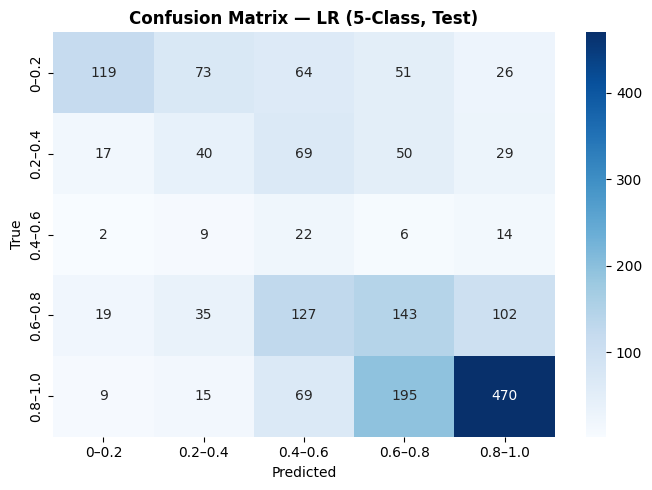

In [19]:
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(bin_scores(y_test), bin_scores(lr_preds), labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'],
            yticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix — LR (5-Class, Test)', fontweight='bold')
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('True')
plt.tight_layout()
plt.show()


## Step 12  Summary Results Table

In [21]:
# See what's in it
for i, r in enumerate(results_table):
    print(i, r['Method'])

0 Common Word Count
1 TF-IDF Cosine Similarity
2 SBERT Cosine Similarity
3 SBERT Direct Predictor
4 BiLSTM Direct Predictor
5 SVR (All Features)
6 Linear Regression (All Features)


In [22]:
results_table = [r for r in results_table if r['Method'] != 'SBERT Direct Predictor (Option A)']

In [23]:
# See what's in it
for i, r in enumerate(results_table):
    print(i, r['Method'])

0 Common Word Count
1 TF-IDF Cosine Similarity
2 SBERT Cosine Similarity
3 SBERT Direct Predictor
4 BiLSTM Direct Predictor
5 SVR (All Features)
6 Linear Regression (All Features)



FINAL RESULTS — TEST SET
                                  Pearson r     MAE    RMSE     QWK
Method                                                             
Common Word Count                    0.2891  0.5783  0.6745  0.0197
TF-IDF Cosine Similarity             0.4020  0.3962  0.4824  0.2302
SBERT Cosine Similarity              0.4351  0.2978  0.3577  0.3729
SBERT Direct Predictor               0.6681  0.2101  0.2833  0.6373
BiLSTM Direct Predictor              0.5959  0.2356  0.3044  0.5495
SVR (All Features)                   0.6028  0.2272  0.3085  0.5810
Linear Regression (All Features)     0.6178  0.2211  0.3006  0.5763
Pearson r: higher better | MAE: lower better | QWK: higher better


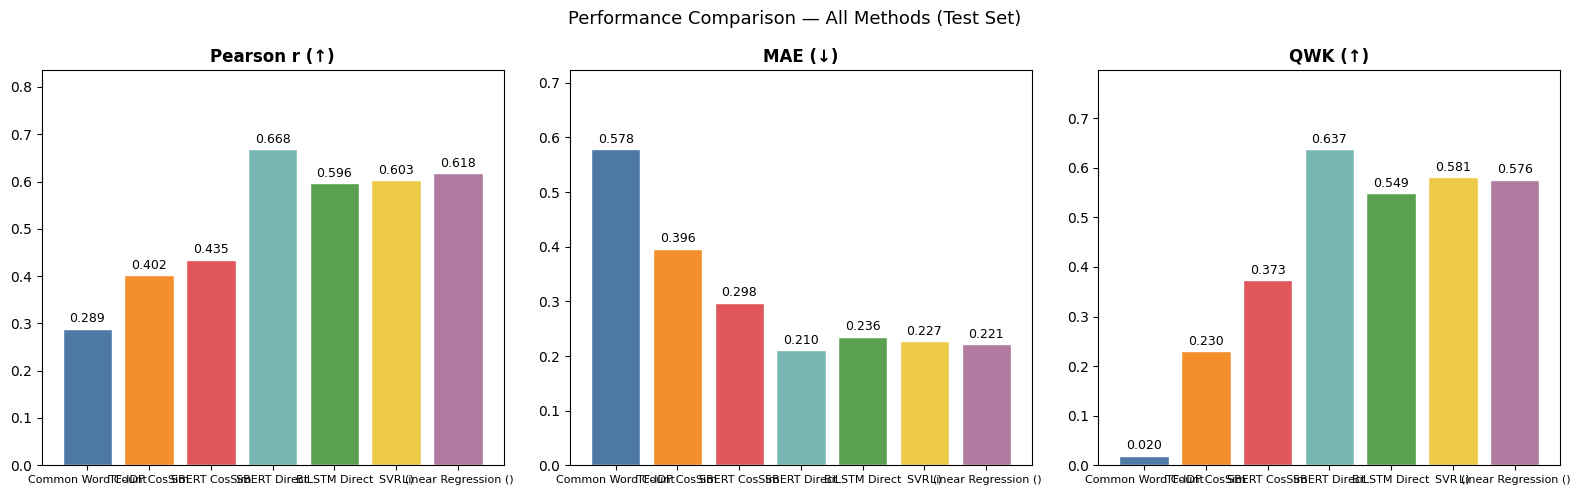

In [24]:
summary = pd.DataFrame(results_table).set_index('Method')
print('\n' + '='*65)
print('FINAL RESULTS — TEST SET')
print('='*65)
print(summary.to_string())
print('='*65)
print('Pearson r: higher better | MAE: lower better | QWK: higher better')

# ── First summary bar chart (3 metrics: Pearson r, MAE, QWK) ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_palette = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1','#ff9da7']
short_names = (
    summary.index
    .str.replace("Cosine Similarity", "CosSim", regex=False)
    .str.replace("Direct Predictor",  "Direct",  regex=False)
    .str.replace("All Features",       "",        regex=False)
    .str.strip()
    .tolist()
)
bar_colors = _palette[:len(short_names)]

for ax, metric, title in zip(
    axes,
    ['Pearson r', 'MAE', 'QWK'],
    ['Pearson r (↑)', 'MAE (↓)', 'QWK (↑)']
):
    vals = summary[metric].values
    bars = ax.bar(short_names, vals, color=bar_colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.25)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Performance Comparison — All Methods (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

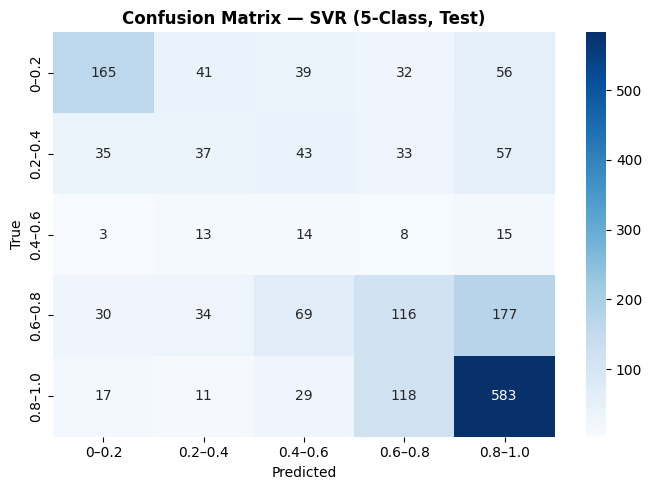

In [25]:
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(bin_scores(y_test), bin_scores(svr_preds), labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'],
            yticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix — SVR (5-Class, Test)', fontweight='bold')
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('True')
plt.tight_layout()
plt.show()


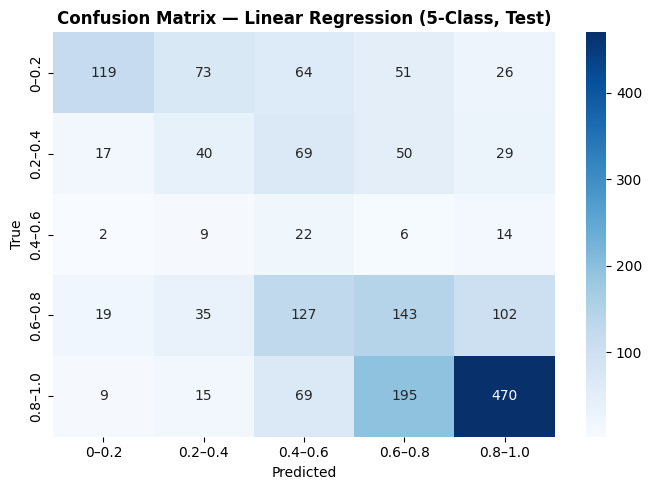

In [26]:
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(bin_scores(y_test), bin_scores(lr_preds), labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'],
            yticklabels=['0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix — Linear Regression (5-Class, Test)', fontweight='bold')
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('True')
plt.tight_layout()
plt.show()

## Step 13  Batch Evaluation Across Multiple Questions & Overall Accuracy


In [43]:

test_cases = [
    # ── Q1:
    (
        "What is photosynthesis?",
        "Photosynthesis is the process by which plants use sunlight, water, "
        "and carbon dioxide to produce glucose and oxygen.",
        "Plants capture light energy from the sun and combine it with H2O "
        "absorbed through roots and CO2 from the air to synthesize sugar, "
        "releasing O2 as a byproduct.",
        0.95
    ),

    # ── Q2:
    (
        "What is the function of red blood cells?",
        "Red blood cells transport oxygen from the lungs to the rest of the "
        "body and carry carbon dioxide back to the lungs for exhalation.",
        "Erythrocytes are responsible for delivering O2 from the respiratory "
        "system to tissues throughout the body and returning CO2 to be expelled.",
        0.92
    ),


    # ── Q3:
    (
        "Why does the Moon orbit the Earth?",
        "The Moon orbits the Earth because of gravity. Earth's gravitational pull "
        "constantly attracts the Moon toward it, and the Moon's forward velocity "
        "balances this pull, resulting in a stable circular orbit.",
        "The Moon stays near Earth because of gravity, which pulls it in our direction. "
        "However gravity also prevents the Moon from completing a full orbit, "
        "which is why it always shows the same face toward Earth.",
        0.45
    ),

    # ── Q4: SBERT MLP FAILURE CASE

    (

        "How do vaccines work?",
        "Vaccines introduce a weakened or inactive form of a pathogen into the body, "
        "triggering the immune system to produce antibodies without causing disease. "
        "This builds memory so the body can fight the real pathogen faster in future.",
        "Vaccines work by exposing the immune system to a harmless version of a disease, "
        "which causes it to produce antibodies. However the immune system is temporarily "
        "weakened after vaccination which is why some people feel unwell.",
        0.30
    ),


]

# ─────────────────────────────────────────────────────────────────────────────

def grade_single(question, reference, student_answer):
    clean_ref_s = preprocess_single(reference)
    clean_stu_s = preprocess_single(student_answer)

    cw = float(np.clip(common_word_count(clean_ref_s, clean_stu_s) / max_cw, 0, 1))

    tfidf_s = float(cosine_similarity(tfidf.transform([clean_ref_s]),
                                      tfidf.transform([clean_stu_s]))[0][0])

    ref_emb = sbert_model.encode([reference], convert_to_tensor=True)
    stu_emb = sbert_model.encode([student_answer], convert_to_tensor=True)
    sbert_s = float(util.cos_sim(ref_emb, stu_emb)[0][0].cpu())

    lstm_model.eval()
    with torch.no_grad():
        stu_enc = torch.tensor([encode_text(clean_stu_s)], dtype=torch.long).to(DEVICE)
        ref_enc = torch.tensor([encode_text(clean_ref_s)], dtype=torch.long).to(DEVICE)
        lstm_s  = float(lstm_model(stu_enc, ref_enc).cpu())

    sbert_grader.eval()
    with torch.no_grad():
        pair_emb = torch.cat([stu_emb, ref_emb], dim=1).cpu().float()
        sbert_mlp_s = float(sbert_grader(pair_emb.to(DEVICE)).cpu())

    feat_vec = np.array([[cw, tfidf_s, sbert_s, lstm_s]])
    svr_s = float(np.clip(svr.predict(feat_vec)[0], 0, 1))
    lr_s  = float(np.clip(lr.predict(feat_vec)[0],  0, 1))

    return {
        'Common Word Count'     : cw,
        'TF-IDF CosSim'         : tfidf_s,
        'SBERT CosSim'          : sbert_s,
        'BiLSTM'                : lstm_s,
        'SBERT MLP Head'        : sbert_mlp_s,
        'SVR (All Features)'    : svr_s,
        'Linear Reg (All Feat)' : lr_s,
    }


# ── Run all test cases ────────────────────────────────────────────────────────
records = []
for q, ref, stu, actual in test_cases:
    preds = grade_single(q, ref, stu)
    for model_name, pred in preds.items():
        records.append({
            'Question'       : q[:55] + '...' if len(q) > 55 else q,
            'Model'          : model_name,
            'Predicted'      : pred,
            'Actual'         : actual,
            'Absolute Error' : abs(pred - actual),
            'Squared Error'  : (pred - actual) ** 2,
            'Accuracy %'     : max(0, (1 - abs(pred - actual) / actual) * 100) if actual > 0 else 0,
        })

results_df = pd.DataFrame(records)

# ── Per-question breakdown ────────────────────────────────────────────────────
print("=" * 75)
print("PER-QUESTION PREDICTIONS")
print("=" * 75)
for q_text in results_df['Question'].unique():
    subset = results_df[results_df['Question'] == q_text].copy()
    actual = subset['Actual'].iloc[0]
    print(f"\nQ: {q_text}")
    print(f"   Actual score: {actual:.2f}")
    print(f"   {'Model':<25} {'Predicted':>10} {'Abs Error':>10} {'Accuracy %':>11}")
    print(f"   {'-'*58}")
    for _, row in subset.sort_values('Absolute Error').iterrows():
        print(f"   {row['Model']:<25} {row['Predicted']:>10.4f} "
              f"{row['Absolute Error']:>10.4f} {row['Accuracy %']:>10.1f}%")



PER-QUESTION PREDICTIONS

Q: What is photosynthesis?
   Actual score: 0.95
   Model                      Predicted  Abs Error  Accuracy %
   ----------------------------------------------------------
   SBERT MLP Head                0.9308     0.0192       98.0%
   SVR (All Features)            0.8425     0.1075       88.7%
   SBERT CosSim                  0.7634     0.1866       80.4%
   Linear Reg (All Feat)         0.7223     0.2277       76.0%
   BiLSTM                        0.6978     0.2522       73.5%
   TF-IDF CosSim                 0.0685     0.8815        7.2%
   Common Word Count             0.0244     0.9256        2.6%

Q: What is the function of red blood cells?
   Actual score: 0.92
   Model                      Predicted  Abs Error  Accuracy %
   ----------------------------------------------------------
   SBERT MLP Head                0.8028     0.1172       87.3%
   SBERT CosSim                  0.7513     0.1687       81.7%
   BiLSTM                        0.4523  

FULL TEST SET ACCURACY )

Model                          MAE     RMSE  Accuracy %
-------------------------------------------------------
SBERT MLP Head              0.2101   0.2833       79.0%
Linear Reg (All Feat)       0.2211   0.3006       77.9%
SVR (All Features)          0.2272   0.3085       77.3%
BiLSTM                      0.2356   0.3044       76.4%
SBERT CosSim                0.2978   0.3577       70.2%
TF-IDF CosSim               0.3962   0.4824       60.4%
Common Word Count           0.5783   0.6745       42.2%

Best model : SBERT MLP Head  (Accuracy: 79.0%,  MAE: 0.2101,  RMSE: 0.2833)


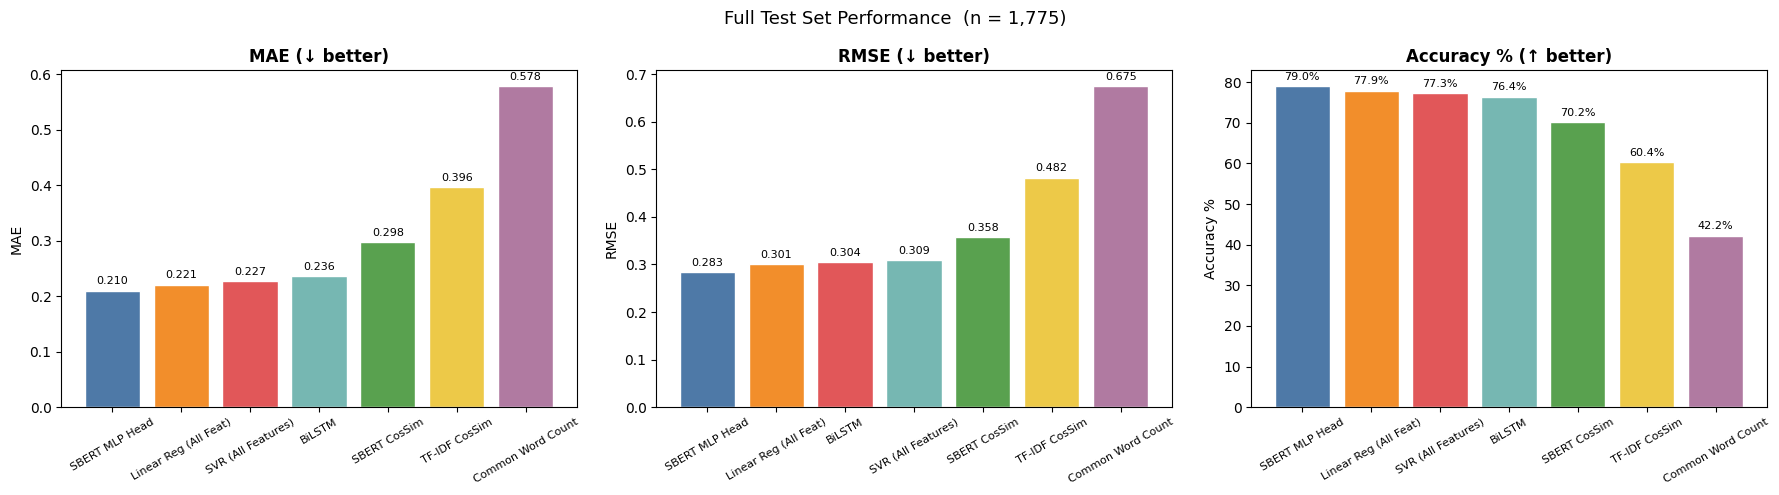

In [44]:
# ── Accuracy Across Entire Test Set ──────────────────────────────────────────

test_preds = {
    'Common Word Count'     : test_df['common_words_norm'].values,
    'TF-IDF CosSim'         : test_df['tfidf_sim'].values,
    'SBERT CosSim'          : test_df['sbert_sim'].values,
    'BiLSTM'                : test_df['lstm_pred'].values,
    'SBERT MLP Head'        : test_df['sbert_pred'].values,
    'SVR (All Features)'    : svr_preds,
    'Linear Reg (All Feat)' : lr_preds,
}

y_true = test_df['score'].values

records_full = []
for model_name, preds in test_preds.items():
    abs_errors = np.abs(preds - y_true)
    records_full.append({
        'Model'      : model_name,
        'MAE'        : np.mean(abs_errors),
        'RMSE'       : np.sqrt(np.mean((preds - y_true) ** 2)),
        'Accuracy %' : np.mean((1 - abs_errors) * 100),
    })

full_summary = pd.DataFrame(records_full).sort_values('Accuracy %', ascending=False).reset_index(drop=True)

print("=" * 60)
print(f"FULL TEST SET ACCURACY )")
print("=" * 60)
print(f"\n{'Model':<25} {'MAE':>8} {'RMSE':>8} {'Accuracy %':>11}")
print("-" * 55)
for _, row in full_summary.iterrows():
    print(f"{row['Model']:<25} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} {row['Accuracy %']:>10.1f}%")

best = full_summary.iloc[0]
print(f"\nBest model : {best['Model']}  "
      f"(Accuracy: {best['Accuracy %']:.1f}%,  "
      f"MAE: {best['MAE']:.4f},  "
      f"RMSE: {best['RMSE']:.4f})")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1']

for ax, metric, title, ascending in zip(
    axes,
    ['MAE', 'RMSE', 'Accuracy %'],
    ['MAE (↓ better)', 'RMSE (↓ better)', 'Accuracy % (↑ better)'],
    [True, True, False]
):
    ordered = full_summary.sort_values(metric, ascending=ascending)
    bars = ax.bar(ordered['Model'], ordered[metric], color=bar_colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for bar, val in zip(bars, ordered[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(ordered[metric]) * 0.02,
                f'{val:.1f}%' if metric == 'Accuracy %' else f'{val:.3f}',
                ha='center', fontsize=8)

plt.suptitle(f'Full Test Set Performance  (n = {len(test_df):,})', fontsize=13)
plt.tight_layout()
plt.savefig('full_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()